In [51]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
data_dir = '/content/drive/MyDrive/CCRI/CCRR_repo/data'
source_folder = f"{data_dir}/misc/"


df_P1 = pd.read_csv(os.path.join(source_folder, 'Merged_Exposure_Data.csv'))
#df_P1 = df_P1.dropna()
df_P2 = pd.read_csv(os.path.join(source_folder, 'P2_Merged_Normalized_avg.csv'))


In [54]:
df_P1.columns

Index(['iso3', 'river_flood_absolute', 'river_flood_relative',
       'coastal_flood_absolute', 'coastal_flood_relative',
       'tropical_storm_absolute', 'tropical_storm_relative',
       'agricultural_drought_absolute', 'agricultural_drought_relative',
       'drought_spei_absolute', 'drought_spei_relative',
       'drought_spi_absolute', 'drought_spi_relative',
       'heatwave_frequency_absolute', 'heatwave_frequency_relative',
       'heatwave_duration_absolute', 'heatwave_duration_relative',
       'heatwave_severity_absolute', 'heatwave_severity_relative',
       'extreme_heat_absolute', 'extreme_heat_relative', 'fire_FRP_absolute',
       'fire_FRP_relative', 'fire_frequency_absolute',
       'fire_frequency_relative', 'sand_dust_absolute', 'sand_dust_relative',
       'air_pollution_absolute', 'air_pollution_relative',
       'vectorborne_malariapv_absolute', 'vectorborne_malariapv_relative',
       'vectorborne_malariapf_absolute', 'vectorborne_malariapf_relative'],
      dt

In [55]:
df_P2.columns

Index(['iso3', 'P2_Under_five_covered_by_social_protection_value_normalized',
       'P2_Under_five_mortality_value_normalized',
       'P2_At-least_basic_drinking_water_value_normalized',
       'P2_Child_poverty_value_normalized', 'P2_Child_labor_value_normalized',
       'P2_Basic_hygiene_value_normalized',
       'P2_Child_marriage_value_normalized',
       'P2_Child_Food_Poverty_value_normalized',
       'P2_Skilled_birth_coverage_value_normalized',
       'P2_DTP1_access_value_normalized',
       'P2_Lower_secondary_out_of_school_value_normalized',
       'P2_Learning_poverty_value_normalized',
       'P2_Lower_secondary_completion_rate_value_normalized',
       'P2_At-least_basic_sanitation_value_normalized',
       'P2_DTP3_access_value_normalized',
       'P2_electricity_access_value_normalized',
       'P2_Stunting_value_normalized', 'P2_arithmetic_avg', 'rank_reverse'],
      dtype='object')

In [56]:
import numpy as np
import pandas as pd
from scipy.stats import gmean
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
# Assume df_P1 is already defined

# Group definitions based on prefixes
hazard_groups = {
    'river_flood': ['river_flood'],
    'coastal_flood': ['coastal_flood'],
    'storm': ['tropical_storm'],
    'drought': ['agricultural_drought', 'drought_spei', 'drought_spi'],
    'heatwave': ['heatwave_frequency', 'heatwave_duration', 'heatwave_severity'],
    'extreme_heat': ['extreme_heat'],#version with only frequncy and extreme heat
    'fire': ['fire_FRP', 'fire_frequency'],
    'sand_dust': ['sand_dust'],
    'air_pollution': ['air_pollution'],
    'malaria': ['vectorborne_malariapv', 'vectorborne_malariapf']
}

# Calculate geometric mean for absolute-relative pairs, then normalize
group_mean_columns = []

for group, hazards in hazard_groups.items():
    group_means = []
    for hazard in hazards:
        abs_col = f"{hazard}_absolute"
        rel_col = f"{hazard}_relative"
        mean_col = f"{hazard}_mean"

        df_P1[mean_col] = df_P1[[abs_col, rel_col]].apply(
            lambda row: gmean(row.replace(0, np.nan).dropna()) if len(row.replace(0, np.nan).dropna()) > 0 else np.nan,
            axis=1
        )

        group_means.append(mean_col)

    # Calculate geometric mean within the group
    group_col = f"{group}_gmean"
    df_P1[group_col] = df_P1[group_means].apply(
        lambda row: gmean(row.replace(0, np.nan).dropna()) if len(row.replace(0, np.nan).dropna()) > 0 else np.nan,
        axis=1
    )

    group_mean_columns.append(group_col)

# # Calculate overall geometric mean across groups
# df_P1['P1_geometric_avg'] = df_P1[group_mean_columns].apply(
#     lambda row: gmean(row.replace(0, np.nan).dropna()) if len(row.replace(0, np.nan).dropna()) > 0 else np.nan,
#     axis=1
# )
# Calculate overall geometric mean ONLY if all hazard groups have data
df_P1['P1_geometric_avg'] = df_P1[group_mean_columns].apply(
    lambda row: gmean(row) if not row.isnull().any() else np.nan,
    axis=1
)

In [57]:
p1_group_mean = pd.concat([df_P1[['iso3'] + group_mean_columns]], axis=1)
p1_group_mean.to_csv(os.path.join(source_folder, "p1_group_mean.csv"), index=False)

In [58]:
df_P1[df_P1['iso3']=='FJI']

,iso3,river_flood_absolute,river_flood_relative,coastal_flood_absolute,coastal_flood_relative,tropical_storm_absolute,tropical_storm_relative,agricultural_drought_absolute,agricultural_drought_relative,drought_spei_absolute,...,fire_frequency_mean,fire_gmean,sand_dust_mean,sand_dust_gmean,air_pollution_mean,air_pollution_gmean,vectorborne_malariapv_mean,vectorborne_malariapf_mean,malaria_gmean,P1_geometric_avg
255,FJI,NaN,NaN,5.022705,6.878621,6.20529,10.0,4.902125,2.13888,1.0,...,1.654379,1.530336,1.0,1.0,6.324991,6.324991,1.0,1.0,1.0,NaN


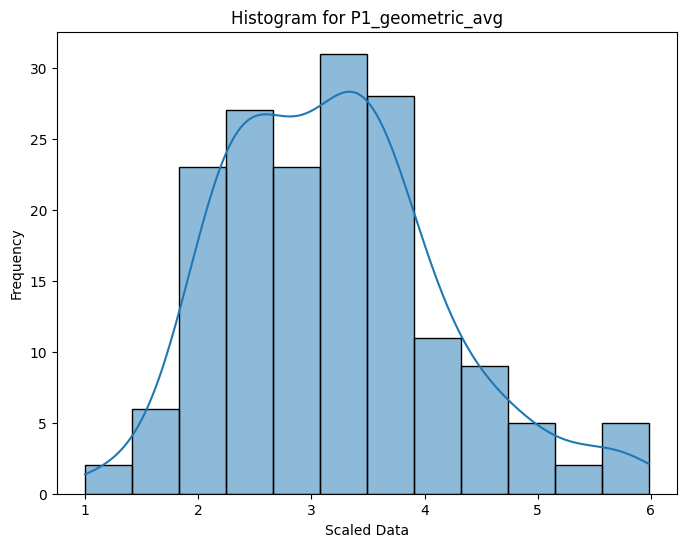

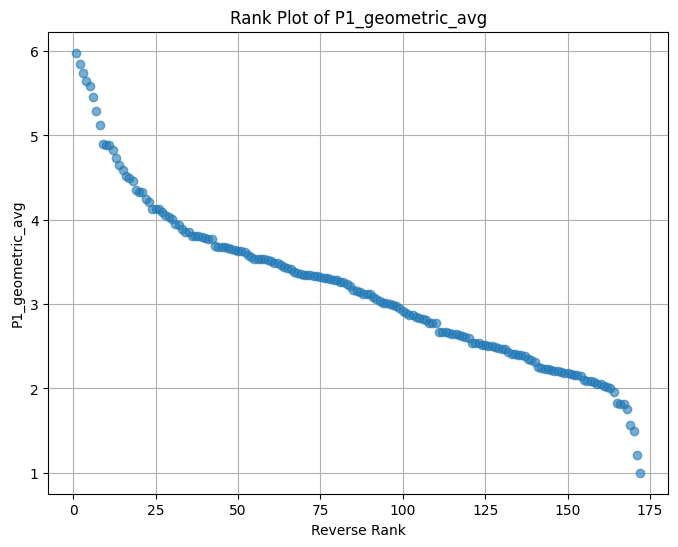

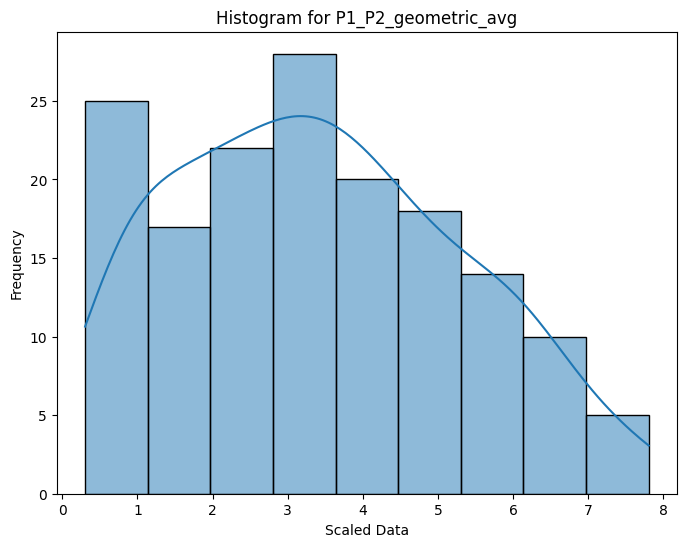

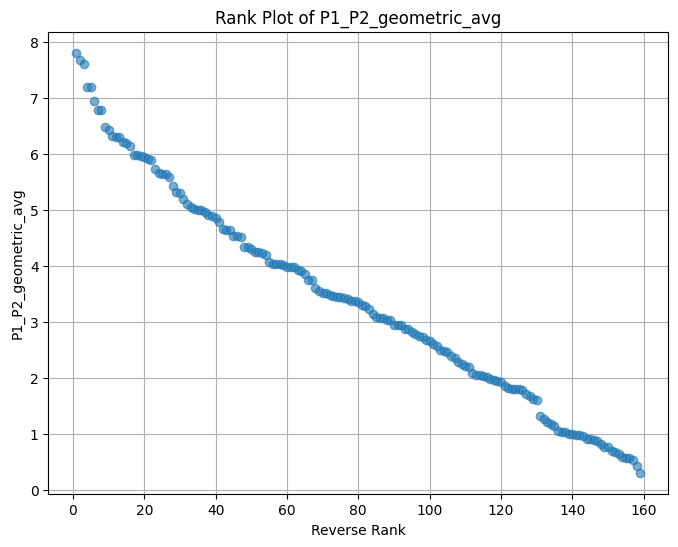

In [59]:

# Plot histogram and normality check
plt.figure(figsize=(8, 6))
sns.histplot(df_P1['P1_geometric_avg'], kde=True)
plt.title(f"Histogram for P1_geometric_avg")
plt.xlabel("Scaled Data")
plt.ylabel("Frequency")
plt.show()

# Compute ranks in reverse order
df_P1['rank_reverse'] = df_P1['P1_geometric_avg'].rank(method='average', ascending=False)
plt.figure(figsize=(8, 6))
plt.plot(df_P1['rank_reverse'], df_P1['P1_geometric_avg'], marker='o', linestyle='', alpha=0.6)
plt.xlabel("Reverse Rank")
plt.ylabel("P1_geometric_avg")
plt.title(f"Rank Plot of P1_geometric_avg")
plt.grid(True)
plt.show()

# Scale the 'P1_geometric_avg' column to range from 0 to 10
scaler = MinMaxScaler(feature_range=(0, 10))  # scale to 0–10
df_P1['P1_geometric_avg'] = scaler.fit_transform(df_P1[['P1_geometric_avg']]).flatten()


# Group by 'ISO3' and calculate the average of 'P1_geometric_avg' for each 'ISO3'
df_P1_grouped = df_P1.groupby('iso3', as_index=False)['P1_geometric_avg'].mean()

# Merge df_P1_grouped with df_P2 on 'ISO3'
merged_df = df_P1_grouped.merge(df_P2[['iso3', 'P2_arithmetic_avg']], left_on='iso3', right_on='iso3', how='left')

# Calculate the Geometric Mean between 'P1_geometric_avg' and 'P2_arithmetic_avg'

merged_df['P1_P2_geometric_avg'] = merged_df.apply(
    lambda row: gmean([
        row['P1_geometric_avg'] + 1e-10,
        row['P2_arithmetic_avg'] + 1e-10
    ]) if not np.isnan(row['P1_geometric_avg']) and not np.isnan(row['P2_arithmetic_avg']) else np.nan,
    axis=1
)

# Plot histogram and normality check
plt.figure(figsize=(8, 6))
sns.histplot(merged_df['P1_P2_geometric_avg'], kde=True)
plt.title(f"Histogram for P1_P2_geometric_avg")
plt.xlabel("Scaled Data")
plt.ylabel("Frequency")
plt.show()

# Compute ranks in reverse order
merged_df['rank_reverse'] = merged_df['P1_P2_geometric_avg'].rank(method='average', ascending=False)
plt.figure(figsize=(8, 6))
plt.plot(merged_df['rank_reverse'], merged_df['P1_P2_geometric_avg'], marker='o', linestyle='', alpha=0.6)
plt.xlabel("Reverse Rank")
plt.ylabel("P1_P2_geometric_avg")
plt.title(f"Rank Plot of P1_P2_geometric_avg")
plt.grid(True)
plt.show()


In [60]:
# Now 'merged_df' contains the scaled 'P1_p2_geometric_avg_scaled'
print(merged_df[['iso3', 'P1_geometric_avg', 'P2_arithmetic_avg', 'P1_P2_geometric_avg']])


    iso3  P1_geometric_avg  P2_arithmetic_avg  P1_P2_geometric_avg
0    ABW               NaN                NaN                  NaN
1    AFG          6.277492           6.332816             6.305093
2    AGO          5.735500           6.188342             5.957620
3    AIA               NaN                NaN                  NaN
4    ALA               NaN                NaN                  NaN
..   ...               ...                ...                  ...
257  xSI               NaN                NaN                  NaN
258  xSK               NaN                NaN                  NaN
259  xSR               NaN                NaN                  NaN
260  xUK               NaN                NaN                  NaN
261  xxx          1.141023                NaN                  NaN

[262 rows x 4 columns]


In [61]:
merged_df.to_csv(os.path.join(source_folder,'p1_p2_avg_ccri.csv'), index=False)

In [62]:
import geopandas as gpd
import pandas as pd

# Load the GeoJSON file as a GeoDataFrame
geo_df = gpd.read_file(os.path.join(source_folder,'georepo_adm0.gpkg'))


In [63]:
geo_df = geo_df[['ISO3', 'uuid', 'name', 'geometry']]

In [64]:
import glob
import os

data_dir = '/content/drive/MyDrive/CCRI/CCRR_repo/data'
exposure_dir = f"{data_dir}/pillar1_data/"

exposure_file =  glob.glob(os.path.join(exposure_dir, '*.csv'))[0]
exposure_df = pd.read_csv(exposure_file)
exposure_df = exposure_df.rename(columns={'exposed': 'child_population_exposed','child_total': 'child_population_total','pop_total': 'population_total'})

exposure_df = exposure_df.groupby('iso3', as_index=False)[['child_population_exposed','child_population_total','population_total']].sum()
geo_df = geo_df.merge(exposure_df[['iso3','child_population_total','population_total']], left_on='ISO3', right_on='iso3', how='left')


In [65]:
geo_df.drop(columns=['iso3'], inplace=True)

In [66]:

# Ensure the key for merging is consistent (e.g., 'ISO3' in df_P1 and 'iso3' in df_P2)
# Merge with merged_df (use 'ISO3' from merged_df and 'iso3' from geo_df or merged_df as needed)

merged_geo_df = geo_df.merge(merged_df, left_on='ISO3', right_on='iso3', how='left')

if 'name' in df_P1.columns:
    df_P1 = df_P1.drop(columns=['name'])

# Ensure only numeric columns are included in the aggregation
numeric_cols = df_P1.select_dtypes(include=[np.number]).columns
df_P1 = df_P1.groupby('iso3', as_index=False)[numeric_cols].mean()


merged_geo_df = merged_geo_df.merge(df_P1, left_on='ISO3', right_on='iso3', how='left')
merged_geo_df = merged_geo_df.merge(df_P2, left_on='ISO3', right_on='iso3', how='left')
merged_geo_df = merged_geo_df.drop(columns=["iso3"])


# Save the merged GeoDataFrame as a new GeoJSON file
output_geojson = os.path.join(source_folder, 'p1_p2_avg_ccri.geojson')
merged_geo_df.to_file(output_geojson, driver='GeoJSON')

print(f"Merged GeoDataFrame saved to {output_geojson}")

Merged GeoDataFrame saved to /content/drive/MyDrive/CCRI/CCRR_repo/data/misc/p1_p2_avg_ccri.geojson


In [67]:
len(merged_geo_df.dropna(subset=['P1_P2_geometric_avg']))

167

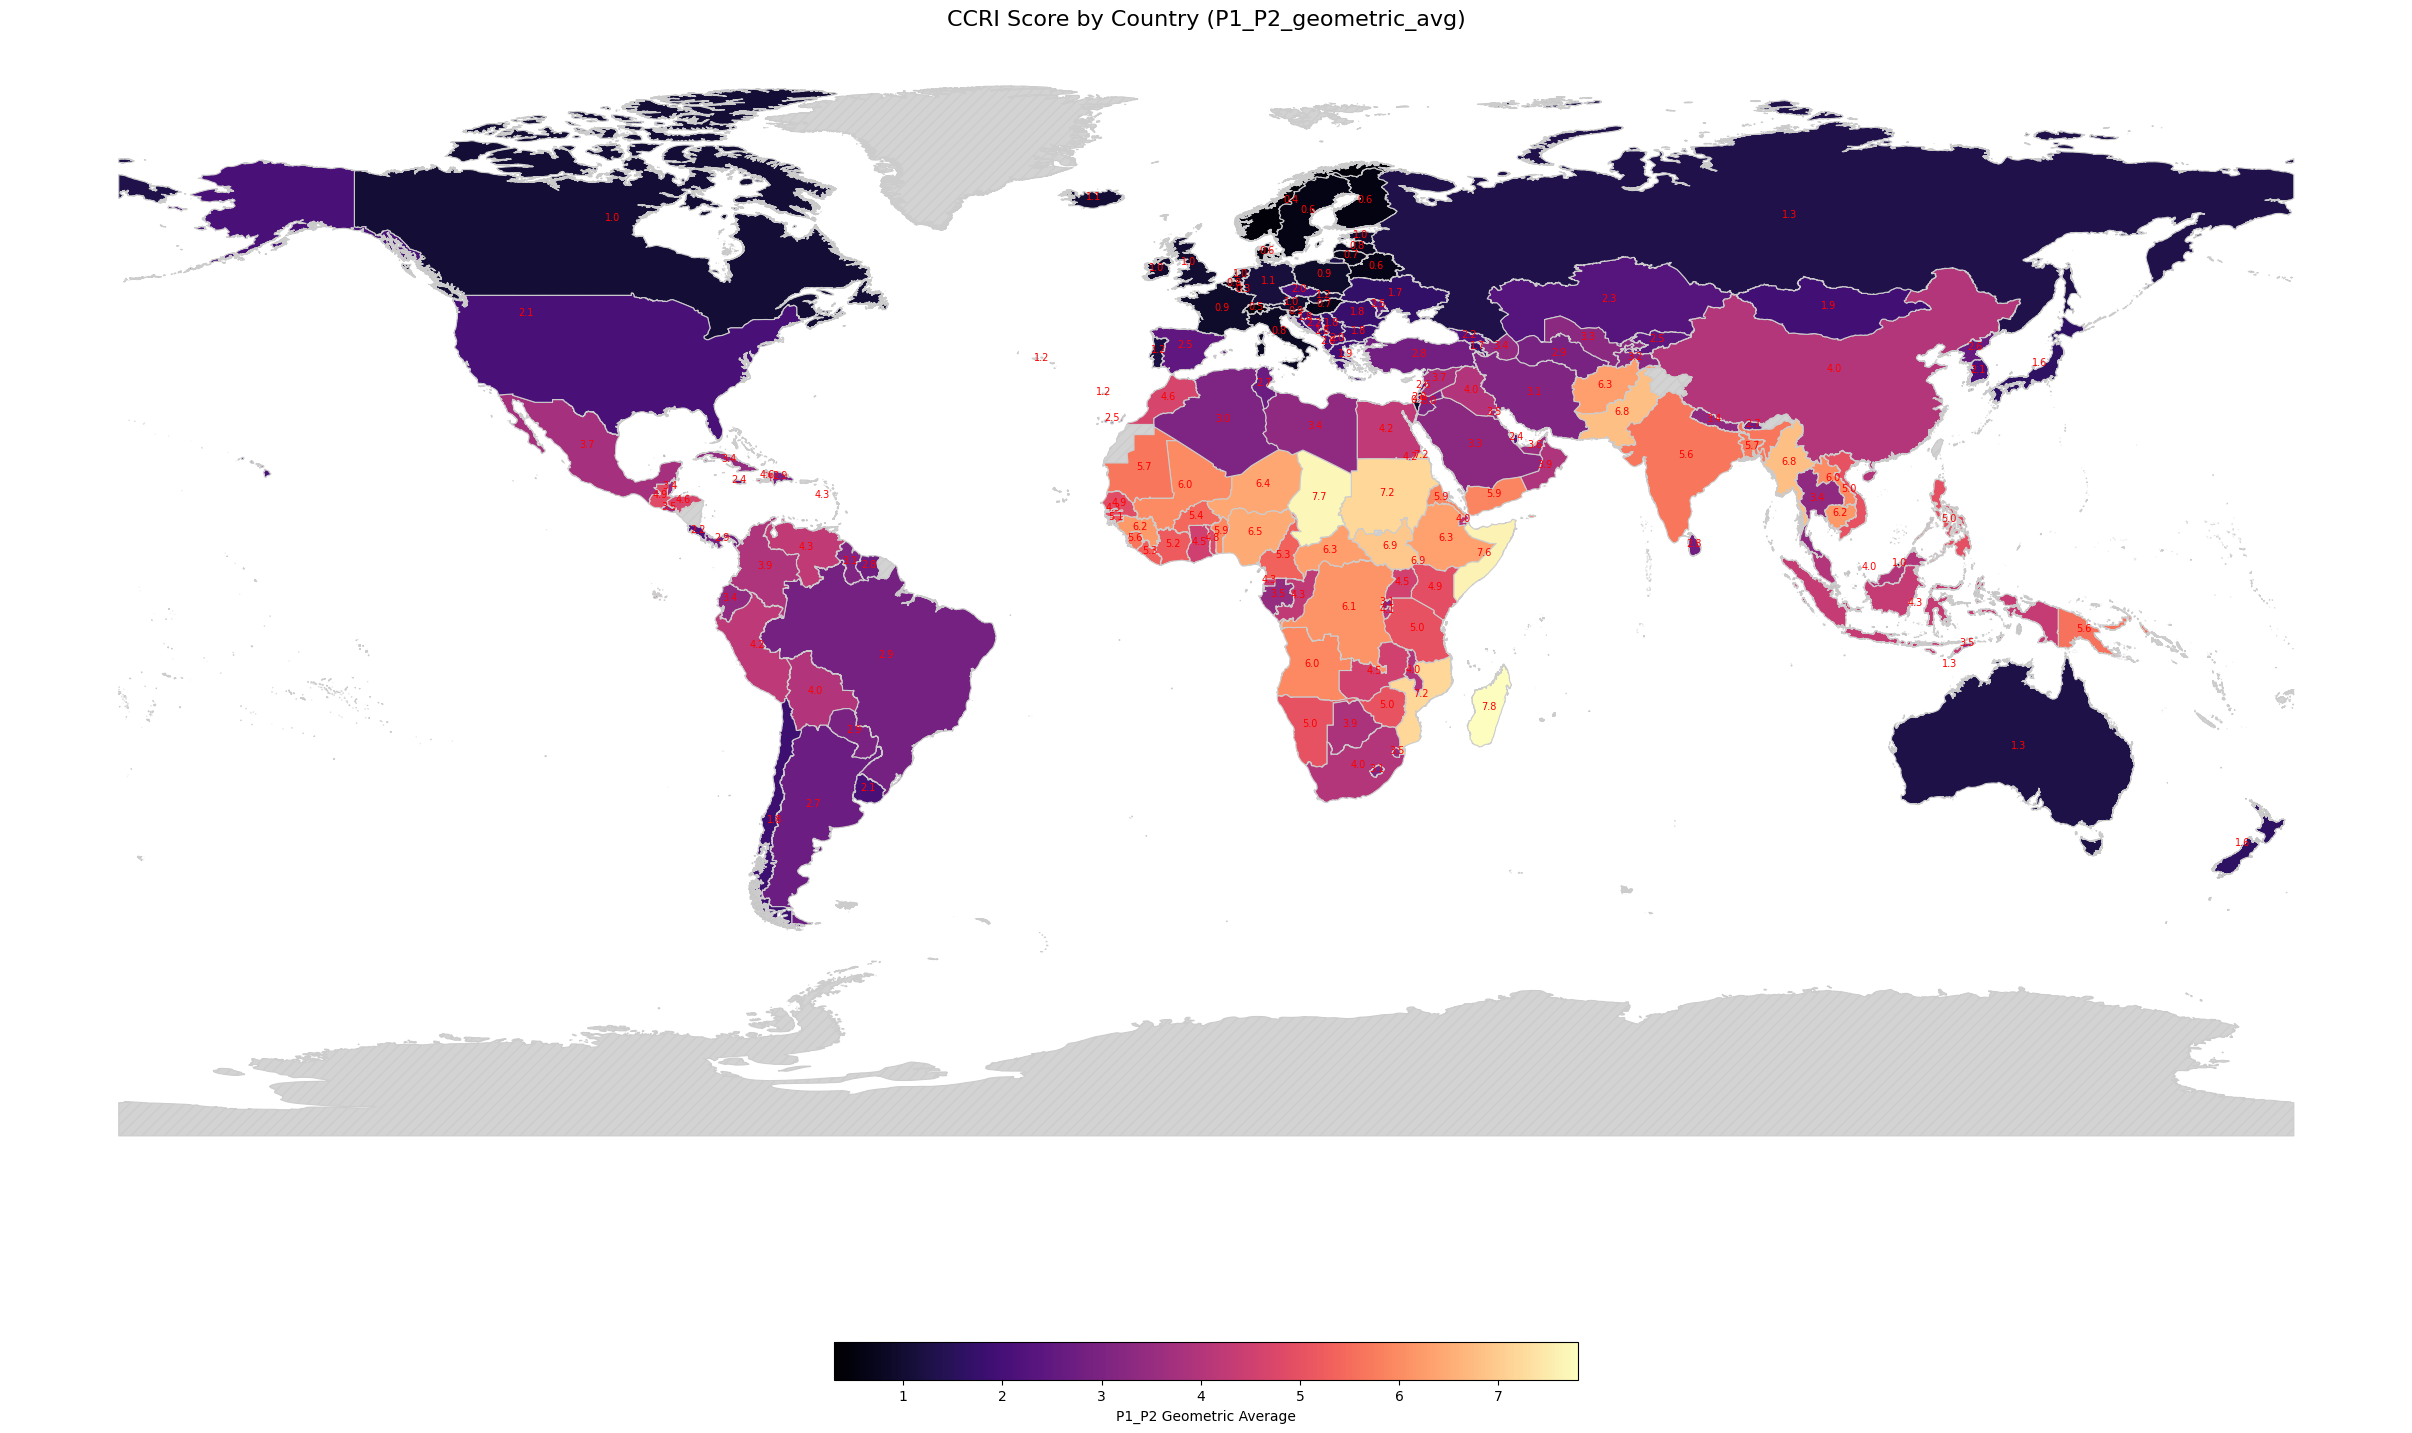

In [68]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd  # Just to be safe in case pd is not imported

fig, ax = plt.subplots(1, 1, figsize=(32, 20))
merged_geo_df.plot(
    column='P1_P2_geometric_avg',
    cmap='magma',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    legend_kwds={
        'shrink': 0.3,      # Reduce legend size
        'label': "P1_P2 Geometric Average",
        'orientation': "horizontal",
        'pad': 0.1
    },
    missing_kwds={
        'color': 'lightgray',       # Fill color for NaN
        'edgecolor': '0.8',         # Edge color for NaN polygons
        'hatch': '///',             # Optional: add pattern to differentiate
        'label': 'No data'
    }
)

# Add labels to non-NaN values
for idx, row in merged_geo_df.iterrows():
    if pd.notnull(row['P1_P2_geometric_avg']):
        centroid = row['geometry'].centroid
        ax.annotate(text=f"{row['P1_P2_geometric_avg']:.1f}", xy=(centroid.x, centroid.y),
                    horizontalalignment='center', fontsize=7, color='red')

# Add title and remove axis
plt.title('CCRI Score by Country (P1_P2_geometric_avg)', fontsize=16)
plt.axis('off')

# Optional: manually add legend entry for NaN
# ax.legend(handles=[Patch(facecolor='lightgray', label='No data')])

plt.show()


In [69]:
np.nanmean(merged_geo_df['P1_P2_geometric_avg'])

np.float64(3.4219884932010127)

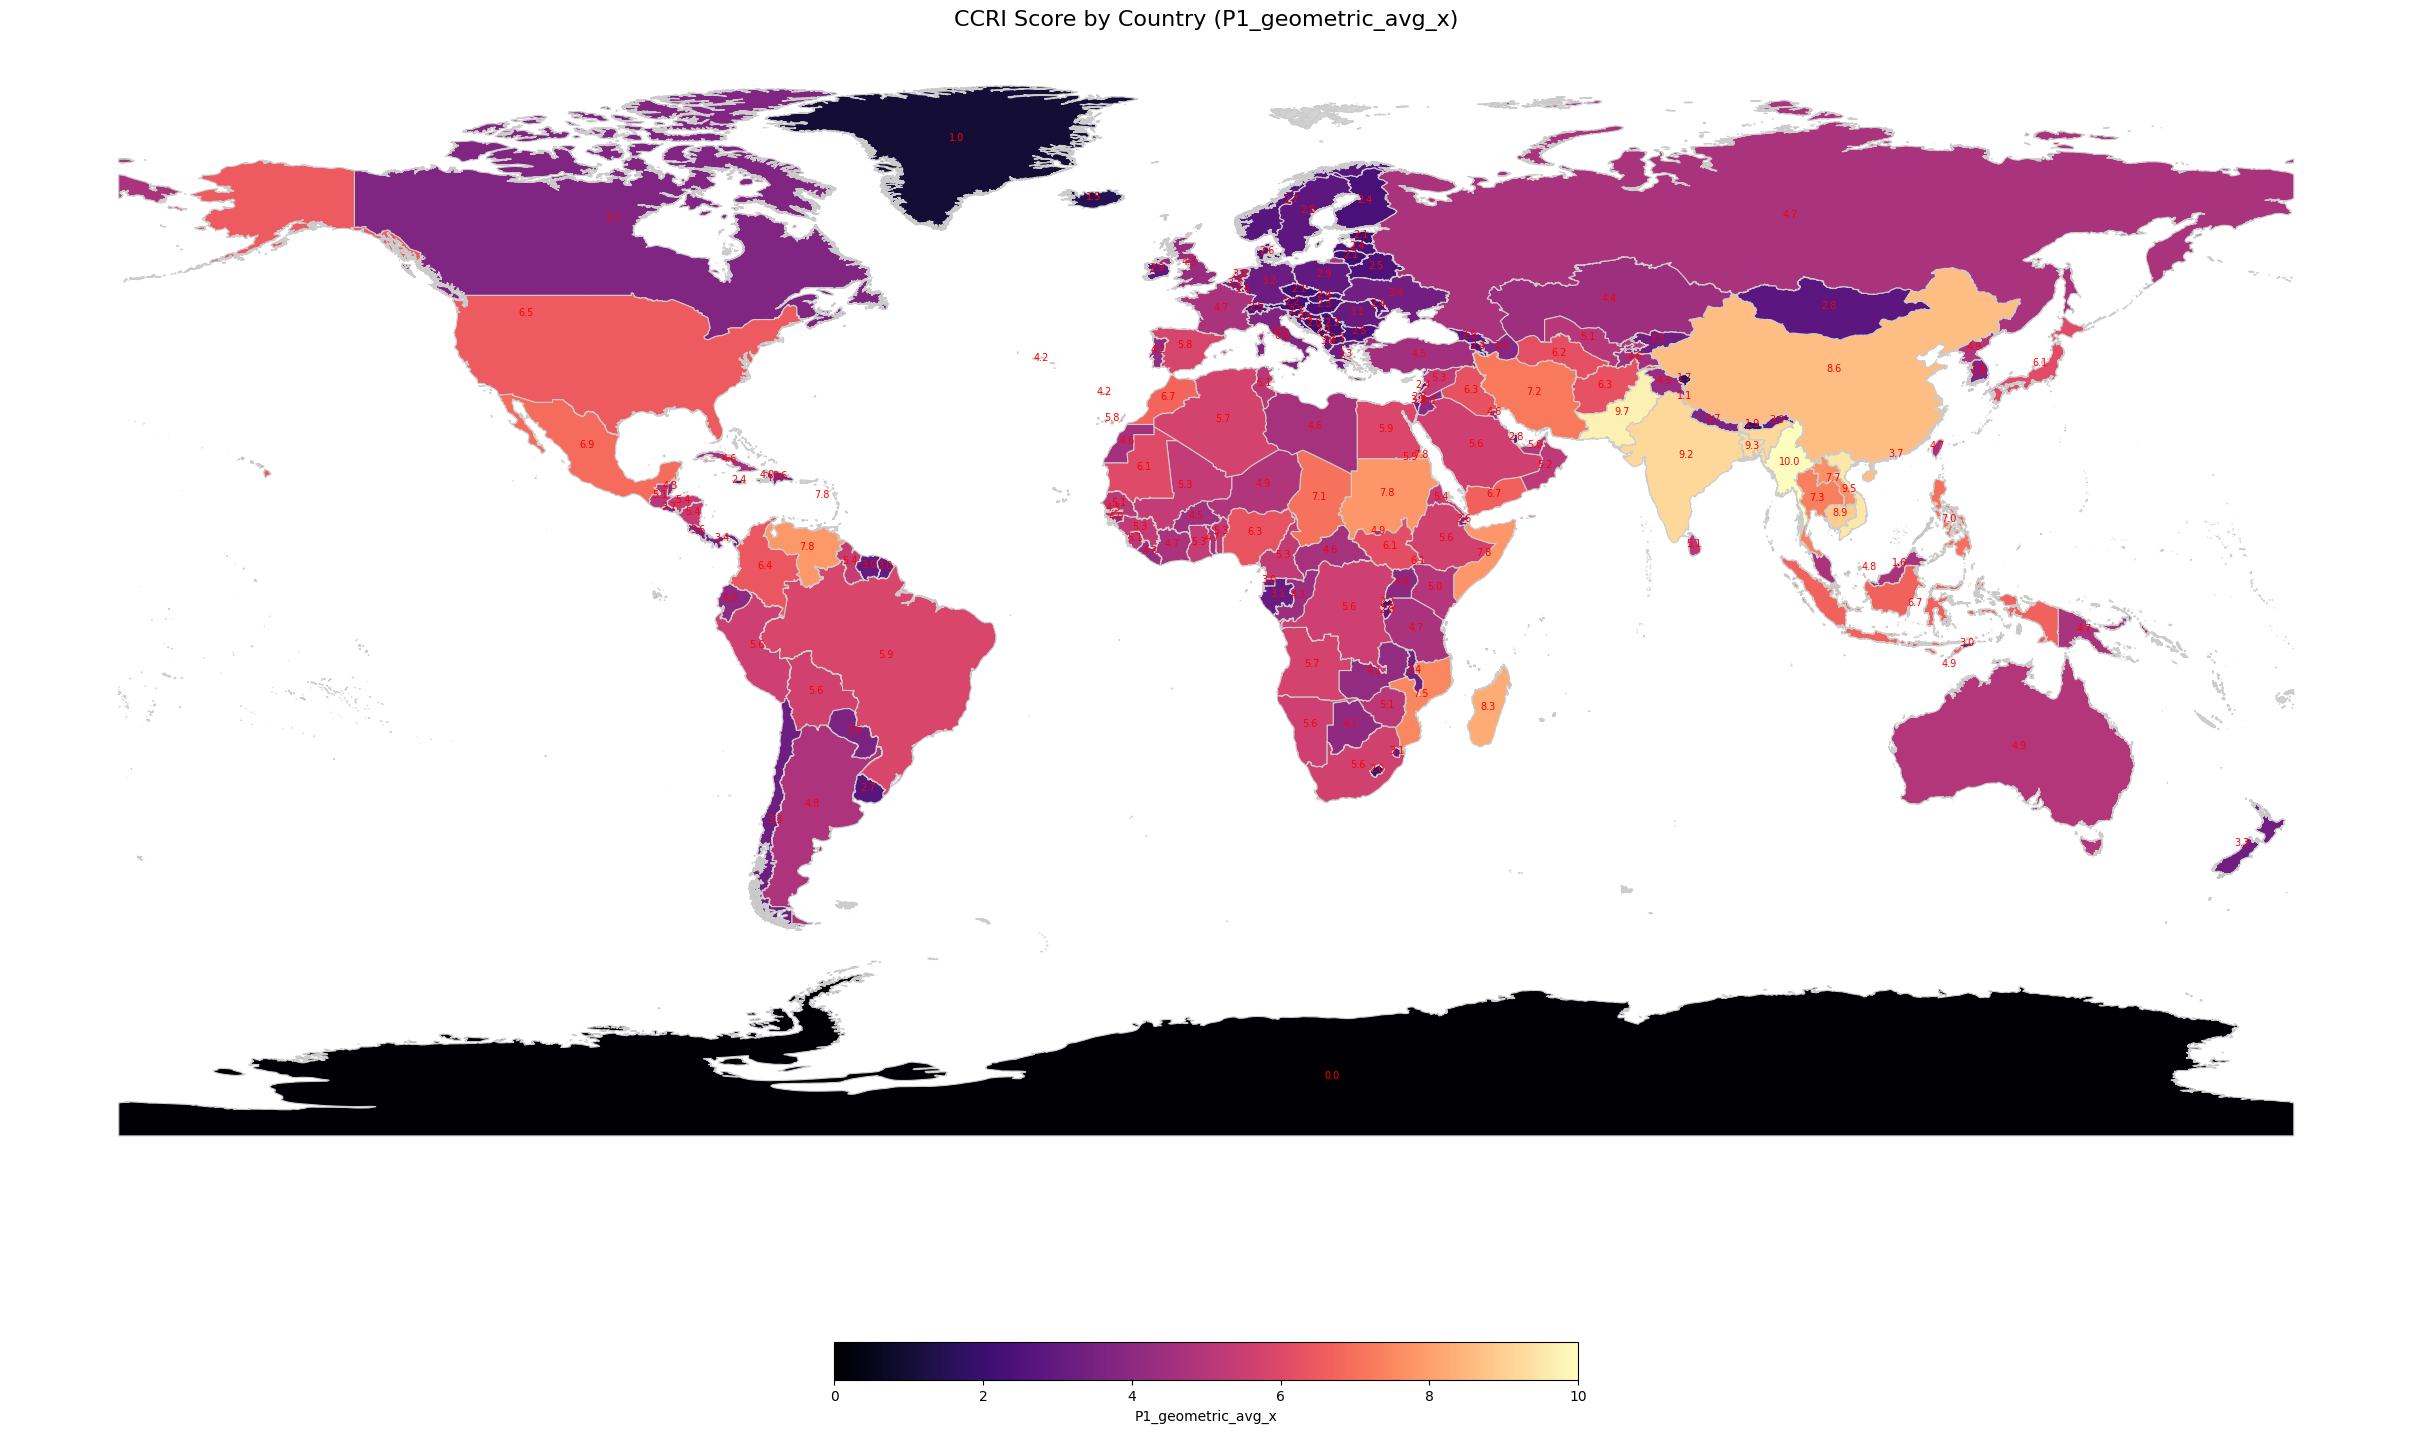

In [70]:
# Attempt to read and plot assuming the file now exists and has 'P1_P2_geometric_avg' column
import geopandas as gpd
import matplotlib.pyplot as plt
import os

fig, ax = plt.subplots(1, 1, figsize=(32, 20))
merged_geo_df.plot(
    column='P1_geometric_avg_x',
    cmap='magma',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    legend_kwds={
        'shrink': 0.3,      # Reduce legend size
        'label': "P1_geometric_avg_x",
        'orientation': "horizontal",
        'pad': 0.1
    },
    missing_kwds={
        'color': 'lightgray',       # Fill color for NaN
        'edgecolor': '0.8',         # Edge color for NaN polygons
        'hatch': '///',             # Optional: add pattern to differentiate
        'label': 'No data'
    }
)

# Add labels
for idx, row in merged_geo_df.iterrows():
    if pd.notnull(row['P1_geometric_avg_x']):
        centroid = row['geometry'].centroid
        ax.annotate(text=f"{row['P1_geometric_avg_x']:.1f}", xy=(centroid.x, centroid.y),
                    horizontalalignment='center', fontsize=7, color='red')

plt.title('CCRI Score by Country (P1_geometric_avg_x)', fontsize=16)
plt.axis('off')
plt.show()



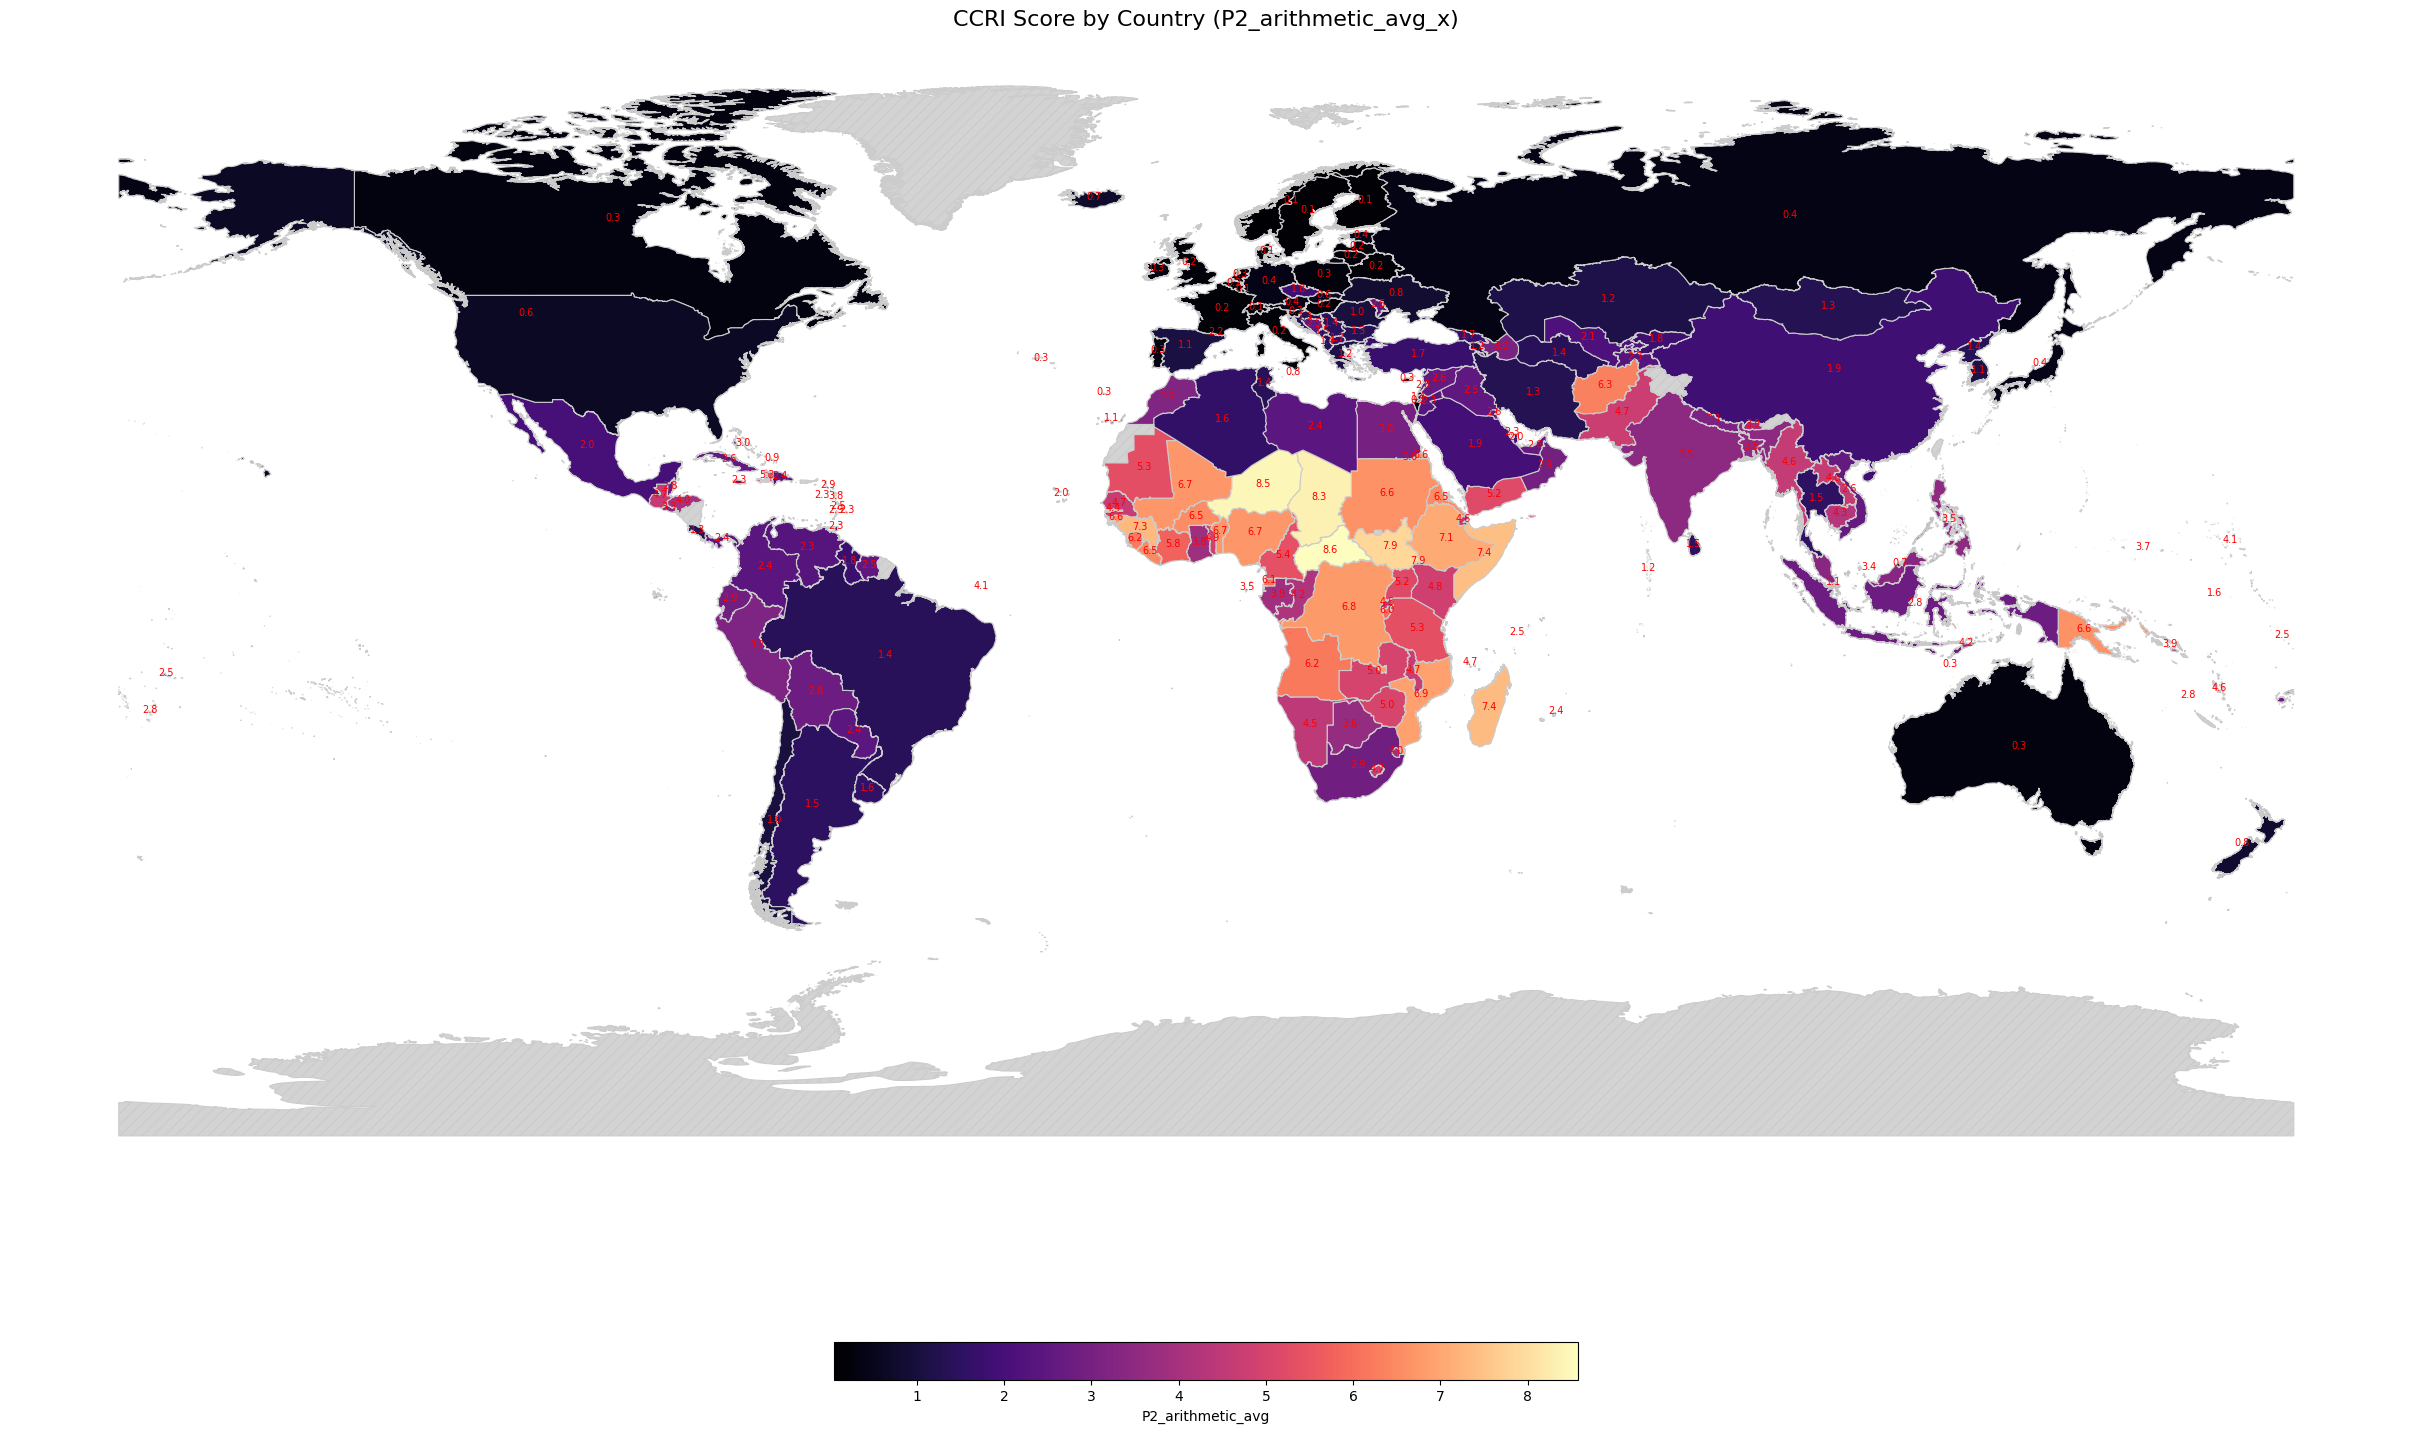

In [71]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd  # Ensure pandas is imported

fig, ax = plt.subplots(1, 1, figsize=(32, 20))
merged_geo_df.plot(
    column='P2_arithmetic_avg_x',
    cmap='magma',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    legend_kwds={
        'shrink': 0.3,
        'label': "P2_arithmetic_avg",
        'orientation': "horizontal",
        'pad': 0.1
    },
    missing_kwds={
        'color': 'lightgray',      # Fill color for NaN
        'edgecolor': '0.8',
        'hatch': '///',            # Optional pattern
        'label': 'No data'
    }
)

# Add labels for valid values
for idx, row in merged_geo_df.iterrows():
    if pd.notnull(row['P2_arithmetic_avg_x']):
        centroid = row['geometry'].centroid
        ax.annotate(
            text=f"{row['P2_arithmetic_avg_x']:.1f}",
            xy=(centroid.x, centroid.y),
            horizontalalignment='center',
            fontsize=7,
            color='red'
        )

plt.title('CCRI Score by Country (P2_arithmetic_avg_x)', fontsize=16)
plt.axis('off')
plt.show()
